# Solving CartPole-v1 with PPO (from scratch)

This notebook demonstrates how to solve the CartPole-v1 environment using a custom implementation of the Proximal Policy Optimization (PPO) algorithm in PyTorch. No external RL libraries are used.

## 1. Install and Import Required Libraries
We will use gymnasium and torch for this implementation.

In [1]:
# Install and import required libraries
import sys
import subprocess

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

try:
    import gymnasium as gym
except ImportError:
    install("gymnasium")
    import gymnasium as gym

try:
    import torch
except ImportError:
    install("torch")
    import torch

import numpy as np
import torch.nn as nn
import torch.optim as optim

## 2. Set Up CartPole-v1 Environment
We will initialize the CartPole-v1 environment and display its basic information.

In [2]:
# Set up the LunarLander-v3 environment
env = gym.make("LunarLander-v3")
obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.n
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)


## 3. Implement PPO Agent
We will define the policy and value networks, and the PPO update step.

In [3]:
# Policy and Value Networks
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, act_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, act_dim)
        )
    def forward(self, x):
        return self.net(x)

class ValueNet(nn.Module):
    def __init__(self, obs_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x)

## 4. Train PPO Agent
We will train the PPO agent on CartPole-v1.

In [ ]:
from torch.distributions.categorical import Categorical

# TODO: generalize into method that can also render N episodes
def evaluate_policy(policy, env_name="LunarLander-v3", n_episodes=20):
    eval_env = gym.make(env_name)
    eval_seed = np.random.randint(0, 1000000)
    episode_rewards, _ = collect_rollouts(policy, eval_env, n_episodes=n_episodes, deterministic=True, render=False, seed=eval_seed)
    mean_reward = np.mean(episode_rewards)
    return mean_reward, episode_rewards

evaluate_policy(PolicyNet(obs_dim, act_dim), n_episodes=5)

(np.float64(-95.69891748683992),
 [np.float64(-3.635505433125047),
  np.float64(-11.518883445818403),
  np.float64(-100.19242158295762),
  np.float64(-281.73255620423174),
  np.float64(-81.4152207680667)])

In [5]:
# Helper functions for PPO
import matplotlib.pyplot as plt
import random

def set_global_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    advantages = []
    gae = 0
    values = values + [0]
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * values[t+1] * (1 - dones[t]) - values[t]
        gae = delta + gamma * lam * (1 - dones[t]) * gae
        advantages.insert(0, gae)
    return advantages

# Set fixed seed for training
TRAIN_SEED = 42
set_global_seed(TRAIN_SEED)
obs, info = env.reset(seed=TRAIN_SEED)

# PPO Training Loop
policy = PolicyNet(obs_dim, act_dim)
value = ValueNet(obs_dim)
policy_optim = optim.Adam(policy.parameters(), lr=1e-4)
value_optim = optim.Adam(value.parameters(), lr=5e-4)

clip_epsilon = 0.15
minibatch_size = 128
gamma = 0.98
lam = 0.92
episodes_per_epoch = 20  # Increased for more stable updates
eval_interval = 5  # Evaluate every n epochs
eval_episodes = 20  # Number of episodes for evaluation
reward_threshold = 200  # LunarLander-v3 solved threshold
#max_epochs = 200  # Safety cap

train_rewards = []  # Store mean reward per epoch
solved = False
current_epoch = 0

while not solved:# and current_epoch < max_epochs:
    obs_buf, act_buf, adv_buf, ret_buf, logp_buf = [], [], [], [], []
    val_buf, rew_buf, done_buf = [], [], []
    episode_rewards = []
    episodes_collected = 0
    obs, info = env.reset()
    done = False
    ep_rews = []
    while episodes_collected < episodes_per_epoch:
        obs_t = torch.as_tensor(obs, dtype=torch.float32)
        logits = policy(obs_t)
        dist = Categorical(logits=logits)
        action = dist.sample()
        logp = dist.log_prob(action)
        value_pred = value(obs_t).item()
        next_obs, reward, terminated, truncated, info = env.step(action.item())
        done_flag = terminated or truncated
        obs_buf.append(obs)
        act_buf.append(action.item())
        logp_buf.append(logp.item())
        val_buf.append(value_pred)
        rew_buf.append(reward)
        done_buf.append(done_flag)
        obs = next_obs
        ep_rews.append(reward)
        if done_flag:
            episode_rewards.append(sum(ep_rews))
            obs, info = env.reset()
            ep_rews = []
            episodes_collected += 1
    if ep_rews:
        episode_rewards.append(sum(ep_rews))
    train_rewards.append(np.mean(episode_rewards))
    adv_buf = compute_gae(rew_buf, val_buf, done_buf, gamma, lam)
    ret_buf = (np.array(adv_buf) + np.array(val_buf)).tolist()
    # Convert buffers to tensors
    obs_tensor = torch.as_tensor(np.array(obs_buf), dtype=torch.float32)
    act_tensor = torch.as_tensor(np.array(act_buf), dtype=torch.int64)
    adv_tensor = torch.as_tensor(np.array(adv_buf), dtype=torch.float32)
    ret_tensor = torch.as_tensor(np.array(ret_buf), dtype=torch.float32)
    logp_old_tensor = torch.as_tensor(np.array(logp_buf), dtype=torch.float32)
    # Normalize advantages
    adv_tensor = (adv_tensor - adv_tensor.mean()) / (adv_tensor.std() + 1e-8)
    # PPO update
    num_samples = len(obs_buf)
    for _ in range(10):
        idx = np.random.permutation(num_samples)
        for start in range(0, num_samples, minibatch_size):
            end = start + minibatch_size
            mb_idx = idx[start:end]
            logits = policy(obs_tensor[mb_idx])
            dist = Categorical(logits=logits)
            logp = dist.log_prob(act_tensor[mb_idx])
            ratio = torch.exp(logp - logp_old_tensor[mb_idx])
            surr1 = ratio * adv_tensor[mb_idx]
            surr2 = torch.clamp(ratio, 1 - clip_epsilon, 1 + clip_epsilon) * adv_tensor[mb_idx]
            policy_loss = -torch.min(surr1, surr2).mean()
            value_pred = value(obs_tensor[mb_idx]).squeeze()
            value_loss = ((ret_tensor[mb_idx] - value_pred) ** 2).mean()
            policy_optim.zero_grad()
            policy_loss.backward()
            policy_optim.step()
            value_optim.zero_grad()
            value_loss.backward()
            value_optim.step()
    current_epoch += 1
    print(f"Epoch {current_epoch} complete. Mean train reward: {train_rewards[-1]:.2f}")
    if current_epoch % eval_interval == 0:
        mean_eval_reward, _ = evaluate_policy(policy, n_episodes=eval_episodes)
        print(f"Evaluation after {current_epoch} epochs: Mean reward = {mean_eval_reward:.2f}")
        if mean_eval_reward >= reward_threshold:
            print(f"Solved! Mean evaluation reward {mean_eval_reward:.2f} >= {reward_threshold}")
            solved = True

Epoch 1 complete. Mean train reward: -241.59
Epoch 2 complete. Mean train reward: -195.26
Epoch 2 complete. Mean train reward: -195.26
Epoch 3 complete. Mean train reward: -170.00
Epoch 3 complete. Mean train reward: -170.00
Epoch 4 complete. Mean train reward: -187.93
Epoch 4 complete. Mean train reward: -187.93
Epoch 5 complete. Mean train reward: -175.16
Epoch 5 complete. Mean train reward: -175.16
Evaluation after 5 epochs: Mean reward = -164.46
Evaluation after 5 epochs: Mean reward = -164.46
Epoch 6 complete. Mean train reward: -152.71
Epoch 6 complete. Mean train reward: -152.71
Epoch 7 complete. Mean train reward: -109.64
Epoch 7 complete. Mean train reward: -109.64
Epoch 8 complete. Mean train reward: -219.70
Epoch 8 complete. Mean train reward: -219.70
Epoch 9 complete. Mean train reward: -179.51
Epoch 9 complete. Mean train reward: -179.51
Epoch 10 complete. Mean train reward: -167.25
Epoch 10 complete. Mean train reward: -167.25
Evaluation after 10 epochs: Mean reward = -22

In [ ]:
# Helper functions for PPO
import matplotlib.pyplot as plt
import random

def set_global_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    advantages = []
    gae = 0
    values = values + [0]
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * values[t+1] * (1 - dones[t]) - values[t]
        gae = delta + gamma * lam * (1 - dones[t]) * gae
        advantages.insert(0, gae)
    return advantages

def collect_rollouts(policy, env, n_episodes=1, deterministic=False, render=False, seed=None):
    """
    Collect rollouts using the given policy and environment.
    Returns: list of episode rewards, and (obs, actions, rewards, dones, logps, values) for all steps.
    """
    from torch.distributions.categorical import Categorical
    episode_rewards = []
    obs_buf, act_buf, rew_buf, done_buf, logp_buf, val_buf = [], [], [], [], [], []
    if seed is not None:
        obs, info = env.reset(seed=seed)
    else:
        obs, info = env.reset()
    episodes_collected = 0
    ep_rews = []
    while episodes_collected < n_episodes:
        obs_t = torch.as_tensor(obs, dtype=torch.float32)
        logits = policy(obs_t)
        dist = Categorical(logits=logits)
        if deterministic:
            action = dist.probs.argmax().item()
            logp = dist.log_prob(torch.tensor(action))
        else:
            action = dist.sample().item()
            logp = dist.log_prob(torch.tensor(action))
        value_pred = None
        if hasattr(policy, 'value'):
            value_pred = policy.value(obs_t).item()
        obs_buf.append(obs)
        act_buf.append(action)
        logp_buf.append(logp.item())
        val_buf.append(value_pred if value_pred is not None else 0)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done_flag = terminated or truncated
        rew_buf.append(reward)
        done_buf.append(done_flag)
        ep_rews.append(reward)
        if render:
            env.render()
        obs = next_obs
        if done_flag:
            episode_rewards.append(sum(ep_rews))
            obs, info = env.reset()
            ep_rews = []
            episodes_collected += 1
    return episode_rewards, (obs_buf, act_buf, rew_buf, done_buf, logp_buf, val_buf)

# Set fixed seed for training
TRAIN_SEED = 42
set_global_seed(TRAIN_SEED)
obs, info = env.reset(seed=TRAIN_SEED)

# PPO Training Loop
policy = PolicyNet(obs_dim, act_dim)
value = ValueNet(obs_dim)
policy_optim = optim.Adam(policy.parameters(), lr=1e-4)
value_optim = optim.Adam(value.parameters(), lr=5e-4)

clip_epsilon = 0.15
minibatch_size = 128
gamma = 0.98
lam = 0.92
episodes_per_epoch = 20  # Increased for more stable updates
eval_interval = 5  # Evaluate every n epochs
eval_episodes = 20  # Number of episodes for evaluation
reward_threshold = 200  # LunarLander-v3 solved threshold
#max_epochs = 200  # Safety cap

train_rewards = []  # Store mean reward per epoch
solved = False
current_epoch = 0

while not solved:# and current_epoch < max_epochs:
    # Use collect_rollouts for training
    episode_rewards, (obs_buf, act_buf, rew_buf, done_buf, logp_buf, val_buf) = collect_rollouts(
        policy, env, n_episodes=episodes_per_epoch, deterministic=False, render=False)
    train_rewards.append(np.mean(episode_rewards))
    adv_buf = compute_gae(rew_buf, val_buf, done_buf, gamma, lam)
    ret_buf = (np.array(adv_buf) + np.array(val_buf)).tolist()
    # Convert buffers to tensors
    obs_tensor = torch.as_tensor(np.array(obs_buf), dtype=torch.float32)
    act_tensor = torch.as_tensor(np.array(act_buf), dtype=torch.int64)
    adv_tensor = torch.as_tensor(np.array(adv_buf), dtype=torch.float32)
    ret_tensor = torch.as_tensor(np.array(ret_buf), dtype=torch.float32)
    logp_old_tensor = torch.as_tensor(np.array(logp_buf), dtype=torch.float32)
    # Normalize advantages
    adv_tensor = (adv_tensor - adv_tensor.mean()) / (adv_tensor.std() + 1e-8)
    # PPO update
    num_samples = len(obs_buf)
    for _ in range(10):
        idx = np.random.permutation(num_samples)
        for start in range(0, num_samples, minibatch_size):
            end = start + minibatch_size
            mb_idx = idx[start:end]
            logits = policy(obs_tensor[mb_idx])
            dist = Categorical(logits=logits)
            logp = dist.log_prob(act_tensor[mb_idx])
            ratio = torch.exp(logp - logp_old_tensor[mb_idx])
            surr1 = ratio * adv_tensor[mb_idx]
            surr2 = torch.clamp(ratio, 1 - clip_epsilon, 1 + clip_epsilon) * adv_tensor[mb_idx]
            policy_loss = -torch.min(surr1, surr2).mean()
            value_pred = value(obs_tensor[mb_idx]).squeeze()
            value_loss = ((ret_tensor[mb_idx] - value_pred) ** 2).mean()
            policy_optim.zero_grad()
            policy_loss.backward()
            policy_optim.step()
            value_optim.zero_grad()
            value_loss.backward()
            value_optim.step()
    current_epoch += 1
    print(f"Epoch {current_epoch} complete. Mean train reward: {train_rewards[-1]:.2f}")
    if current_epoch % eval_interval == 0:
        mean_eval_reward, _ = evaluate_policy(policy, n_episodes=eval_episodes)
        print(f"Evaluation after {current_epoch} epochs: Mean reward = {mean_eval_reward:.2f}")
        if mean_eval_reward >= reward_threshold:
            print(f"Solved! Mean evaluation reward {mean_eval_reward:.2f} >= {reward_threshold}")
            solved = True


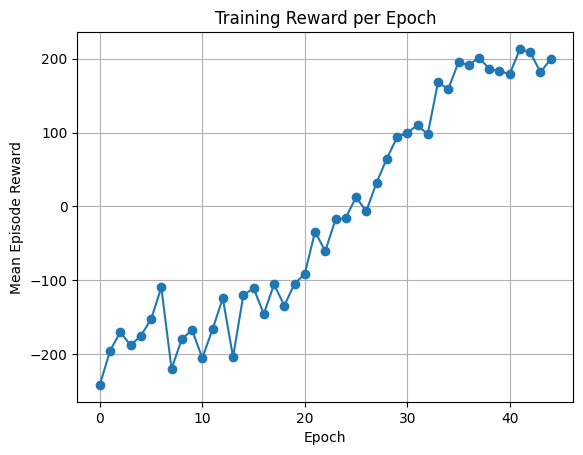

In [6]:
# Plot training rewards after training
import matplotlib.pyplot as plt
plt.plot(train_rewards, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Mean Episode Reward')
plt.title('Training Reward per Epoch')
plt.grid(True)
plt.show()


In [7]:
evaluate_policy(policy, n_episodes=100)

(np.float64(218.41052998342894),
 [np.float64(253.23121684303635),
  np.float64(209.25009888862502),
  np.float64(233.555486976095),
  np.float64(222.25122395259632),
  np.float64(234.89186827003223),
  np.float64(226.1945384531403),
  np.float64(216.44700341330875),
  np.float64(244.57865673267864),
  np.float64(239.75367011421608),
  np.float64(242.72847181724936),
  np.float64(250.0298761829359),
  np.float64(234.61424524955729),
  np.float64(199.5347477744014),
  np.float64(223.89243136133473),
  np.float64(212.04144760990476),
  np.float64(90.05976168075348),
  np.float64(259.29612042393387),
  np.float64(230.1417057728687),
  np.float64(234.53648333056796),
  np.float64(224.9715673105925),
  np.float64(228.69337013444988),
  np.float64(228.68609535289664),
  np.float64(230.42733625087632),
  np.float64(210.13471460907226),
  np.float64(246.6504534085489),
  np.float64(251.97495529335268),
  np.float64(217.23945585969426),
  np.float64(206.8347324805477),
  np.float64(231.89000798

In [8]:
%pip install tsilva-notebook-utils

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [10]:
from tsilva_notebook_utils.gymnasium import render_episode
from tsilva_notebook_utils.gymnasium import build_env

build_env_fn = lambda **kwargs: build_env("LunarLander-v3", **kwargs)

render_episode(
    env=build_env_fn,
    model=policy
)